## Data Sources

This project uses two public tennis datasets:

- Jeff Sackmann’s point-by-point dataset
- Jeff Sackmann’s ATP match dataset

The point-by-point dataset provides the sequence of points within each match, while the ATP dataset provides contextual information such as surface, tournament level, and player rankings.

## Data Enrichment

The original point-by-point data was enriched with match-level ATP information.  

Added features include:
- surface (clay, hard, grass)
- player ranking
- opponent ranking
- rank difference
- tournament information

This enrichment step is important because it makes the analysis more meaningful than using raw point sequences alone.

## Hypotheses

The main hypothesis of this project is that losing a break point leads to a short-term decline in performance.

- **H0:** The mean performance drop after losing a break point is equal to zero.
- **H1:** The mean performance drop after losing a break point is below zero.


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



In [113]:
url = "https://raw.githubusercontent.com/nilugur/dsa210-term-project/main/breakpoint_events.csv"
df = pd.read_csv(url)

df.head()

,match_id,date,tourney_name,surface,tourney_level,pressure_level,round,player,opponent,set_no,...,match_winner,rank_diff,is_underdog,won_match,pbpp_3,pd_3,pbpp_6,pd_6,pbpp_12,pd_12
0,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Gilles Muller,Edouard Roger-Vasselin,2,...,Gilles Muller,-70.0,0,1,1.000000,0.452736,0.833333,0.286070,0.833333,0.286070
1,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.666667,0.213930,0.500000,0.047264,0.333333,-0.119403
2,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.333333,-0.119403,0.333333,-0.119403,0.416667,-0.036070
3,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.000000,-0.452736,0.333333,-0.119403,0.416667,-0.036070
4,7031687,2015-01-05,Chennai,Hard,A,lower,R32,Robin Haase,Borna Coric,1,...,Borna Coric,-15.0,0,0,0.333333,-0.028369,0.166667,-0.195035,0.083333,-0.278369


In [114]:
df[["pbpp_3", "pbpp_6", "pbpp_12", "pd_3", "pd_6", "pd_12"]].isna().sum()

,0
pbpp_3,682
pbpp_6,1110
pbpp_12,2523
pd_3,682
pd_6,1110
pd_12,2523


In [115]:
# Example structure (simplified)

events = pd.read_csv(url)

events["pd_3"] = events["pbpp_3"] - events["baseline_win_rate"]
events["pd_6"] = events["pbpp_6"] - events["baseline_win_rate"]
events["pd_12"] = events["pbpp_12"] - events["baseline_win_rate"]

## Break Point Identification

A break point is defined as a situation where the receiving player can win the game on the next point.

A lost break point event occurs when:
- the player is the receiver
- the score indicates break point
- the player loses the point

After each lost break point, the next k points (k = 3, 6, 12) are tracked.

In [116]:
print("Number of rows:", len(df))
print("Columns:")
print(df.columns)

Number of rows: 36267
Columns:
Index(['match_id', 'date', 'tourney_name', 'surface', 'tourney_level',
       'pressure_level', 'round', 'player', 'opponent', 'set_no', 'game_no',
       'point_index', 'player_rank', 'opponent_rank', 'baseline_win_rate',
       'match_winner', 'rank_diff', 'is_underdog', 'won_match', 'pbpp_3',
       'pd_3', 'pbpp_6', 'pd_6', 'pbpp_12', 'pd_12'],
      dtype='object')


### Missing Values

A small number of missing values appear in the PBPP and PD variables.  
This happens because some break-point events do not have enough following points to compute the selected window completely.

To avoid invalid statistical results, missing values were removed before running the hypothesis tests.

In [117]:
events = events.dropna(subset=["pbpp_3", "pbpp_6", "pbpp_12"])
events = events.drop_duplicates()

## Data Cleaning

- Rows with missing PBPP values are removed
- These occur when fewer than k points remain in the match
- Duplicate rows are removed

## Project Overview

This notebook presents the April 14 milestone of my DSA210 term project.  
The goal is to examine whether professional tennis players experience a short-term performance decline after losing break points.

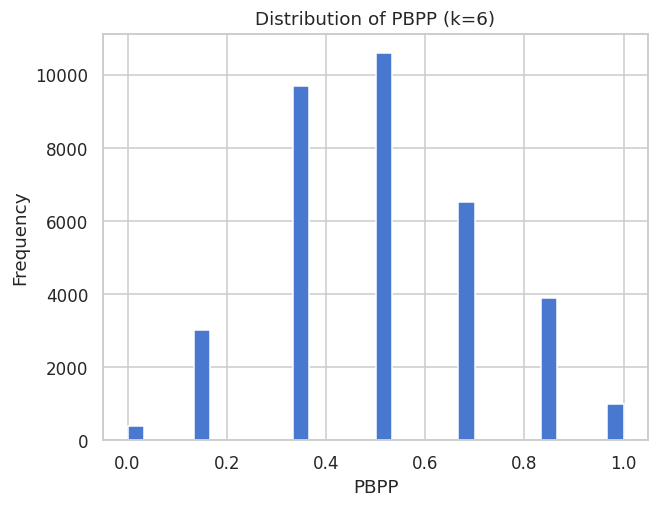

In [118]:
plt.hist(df["pbpp_6"], bins=30)
plt.title("Distribution of PBPP (k=6)")
plt.xlabel("PBPP")
plt.ylabel("Frequency")
plt.show()

### Interpretation of PBPP Distribution

PBPP values are mostly concentrated around the middle range, suggesting that after losing a break point, players often win a moderate share of the following points.  
This gives an initial view of how players perform immediately after high-pressure moments.

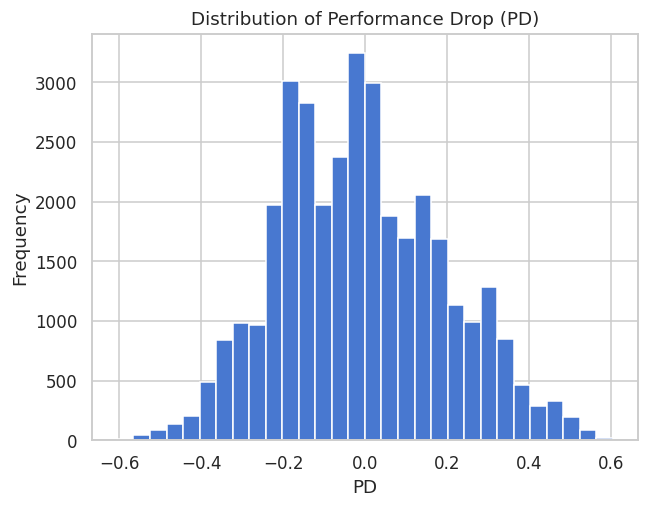

In [119]:
plt.hist(df["pd_6"], bins=30)
plt.title("Distribution of Performance Drop (PD)")
plt.xlabel("PD")
plt.ylabel("Frequency")
plt.show()

### Interpretation of Performance Drop

The PD distribution appears slightly shifted below zero.  
This suggests that players may perform somewhat worse than their usual baseline after losing a break point.

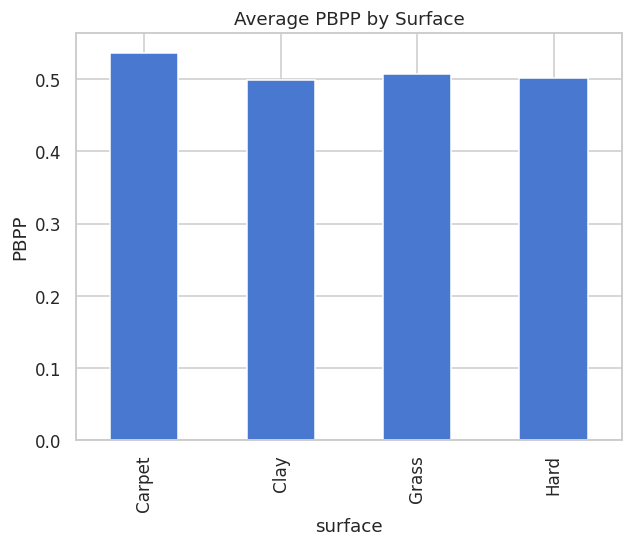

In [120]:
df.groupby("surface")["pbpp_6"].mean().plot(kind="bar")
plt.title("Average PBPP by Surface")
plt.ylabel("PBPP")
plt.show()

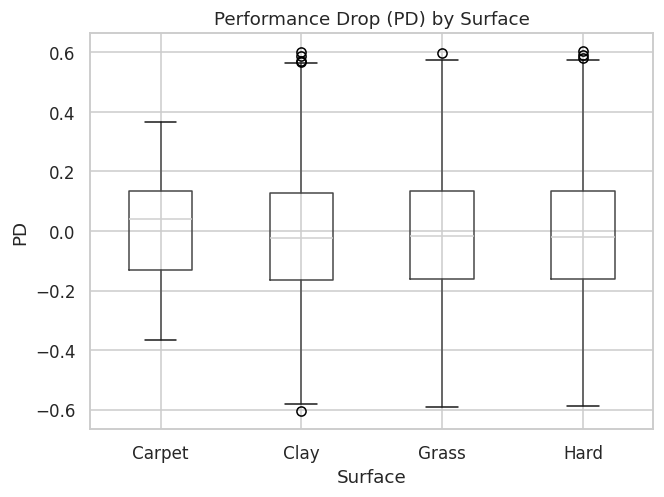

In [121]:
df.boxplot(column="pd_6", by="surface")
plt.title("Performance Drop (PD) by Surface")
plt.suptitle("")
plt.xlabel("Surface")
plt.ylabel("PD")
plt.show()

### Interpretation of PD by Surface

This boxplot shows how performance drop (PD) varies across different court surfaces.
The median PD values are generally below zero, which supports the idea that players tend to perform worse after losing a break point.
There may be some variation across surfaces, but the overall pattern remains negative.

In [122]:
pd6 = df["pd_6"].dropna()
t_stat, p_value = stats.ttest_1samp(pd6, 0)
print("t-statistic:", t_stat)
print("p-value:", p_value)
print("Mean PD:", pd6.mean())

t-statistic: -9.108118734675159
p-value: 8.812349193048484e-20
Mean PD: -0.009850827223298516


### Hypothesis Test Result

After removing missing values, the one-sample t-test on `pd_6` produced a statistically significant result (p < 0.05).  
The mean value of `pd_6` is below zero, which indicates that players tend to perform worse than their baseline after losing a break point.

The mean value of PD is below zero, which confirms that the performance after losing a break point is lower than the baseline performance.

The number of observations used in the test is sufficiently large, which increases the reliability of the statistical result.

This finding supports the main hypothesis of the project: lost break points are associated with a short-term decline in performance.


In [123]:
for k in [3, 6, 12]:
    col = f"pd_{k}"
    vals = df[col].dropna()
    t_stat, p_value = stats.ttest_1samp(vals, 0)
    print(f"{col}:")
    print("  Number of valid observations:", len(vals))
    print("  Mean:", vals.mean())
    print("  t-statistic:", t_stat)
    print("  p-value:", p_value)
    print()

pd_3:
  Number of valid observations: 35585
  Mean: -0.07940550844288813
  t-statistic: -51.6941057983034
  p-value: 0.0

pd_6:
  Number of valid observations: 35157
  Mean: -0.009850827223298516
  t-statistic: -9.108118734675159
  p-value: 8.812349193048484e-20

pd_12:
  Number of valid observations: 33744
  Mean: -0.006805331839019038
  t-statistic: -9.845774312295076
  p-value: 7.67403970090223e-23



### Robustness Across Different Windows

To check whether the result depends on a single short-term window, I repeated the same hypothesis test for `k = 3`, `k = 6`, and `k = 12`.

If the mean values remain below zero and the p-values are statistically significant across these different windows, this means the finding is robust.  
In other words, the performance decline is not limited to one arbitrary definition of “short term,” but appears consistently across multiple horizons.

In [124]:
groups = [group["pd_6"].dropna().values for _, group in df.groupby("surface")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.9333735401535643
p-value: 0.12177117630910833


### Surface Comparison Test

ANOVA is used to test whether average performance drop differs across surfaces.  
If the p-value is small, this suggests that court surface plays a role in short-term post-break-point performance.

## Conclusion

This analysis provides evidence that losing a break point is associated with a short-term drop in performance.  
The effect is visible in the descriptive analysis and supported by hypothesis testing.  

Most important conclusion from the finished analysis:

- the short-term drop is real
- it is strongest in the next 3 points
- it becomes much smaller by 6 and 12 points
- subgroup differences by surface and rank group are very small
- the effect stays stable under robustness checks

Surface differences may also play a role, although this effect should be explored further with broader data coverage.



## Machine Learning Analysis
### Nil Uğur

This notebook applies supervised machine learning to predict whether a player will experience a performance drop (PD < 0) after losing a break point.  
Models covered:
1. Train/Test Split
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. Model Comparison

---
## 0. Imports & Setup

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.inspection import permutation_importance

# Plotting style
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


---
## 1. Load & Inspect Data

In [126]:
# Load the breakpoint events dataset produced by dsa210_tennis_pipeline.py
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (36267, 25)
Columns: ['match_id', 'date', 'tourney_name', 'surface', 'tourney_level', 'pressure_level', 'round', 'player', 'opponent', 'set_no', 'game_no', 'point_index', 'player_rank', 'opponent_rank', 'baseline_win_rate', 'match_winner', 'rank_diff', 'is_underdog', 'won_match', 'pbpp_3', 'pd_3', 'pbpp_6', 'pd_6', 'pbpp_12', 'pd_12']


,match_id,date,tourney_name,surface,tourney_level,pressure_level,round,player,opponent,set_no,...,match_winner,rank_diff,is_underdog,won_match,pbpp_3,pd_3,pbpp_6,pd_6,pbpp_12,pd_12
0,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Gilles Muller,Edouard Roger-Vasselin,2,...,Gilles Muller,-70.0,0,1,1.000000,0.452736,0.833333,0.286070,0.833333,0.286070
1,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.666667,0.213930,0.500000,0.047264,0.333333,-0.119403
2,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3,...,Gilles Muller,70.0,1,0,0.333333,-0.119403,0.333333,-0.119403,0.416667,-0.036070


In [127]:
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
match_id                0
date                    0
tourney_name            0
surface                 0
tourney_level           0
pressure_level          0
round                   0
player                  0
opponent                0
set_no                  0
game_no                 0
point_index             0
player_rank            59
opponent_rank          85
baseline_win_rate       0
match_winner            0
rank_diff             133
is_underdog             0
won_match               0
pbpp_3                682
pd_3                  682
pbpp_6               1110
pd_6                 1110
pbpp_12              2523
pd_12                2523
dtype: int64


In [128]:
df.describe()

,match_id,set_no,game_no,point_index,player_rank,opponent_rank,baseline_win_rate,rank_diff,is_underdog,won_match,pbpp_3,pd_3,pbpp_6,pd_6,pbpp_12,pd_12
count,3.626700e+04,36267.000000,36267.000000,36267.000000,36208.000000,36182.000000,36267.000000,36134.000000,36267.000000,36267.000000,35585.000000,35585.000000,35157.000000,35157.000000,33744.000000,33744.000000
mean,9.254869e+06,1.953153,14.930295,93.621419,71.437169,80.890830,0.511750,-9.625311,0.449086,0.552706,0.432214,-0.079406,0.501887,-0.009851,0.504193,-0.006805
std,1.717428e+06,0.934067,9.937529,63.222724,98.188772,108.568077,0.054038,137.086557,0.497408,0.497221,0.296975,0.289763,0.211286,0.202792,0.137180,0.126969
min,7.031538e+06,1.000000,1.000000,4.000000,1.000000,1.000000,0.260870,-1383.000000,0.000000,0.000000,0.000000,-0.682927,0.000000,-0.606061,0.000000,-0.516279
25%,7.652304e+06,1.000000,7.000000,43.000000,20.000000,27.000000,0.475962,-45.000000,0.000000,0.000000,0.333333,-0.223485,0.333333,-0.161994,0.416667,-0.089130
50%,8.344319e+06,2.000000,14.000000,85.000000,47.000000,54.000000,0.511450,-7.000000,0.000000,1.000000,0.333333,-0.147636,0.500000,-0.020202,0.500000,-0.008819
75%,1.103399e+07,3.000000,21.000000,132.000000,86.000000,93.000000,0.547059,32.000000,1.000000,1.000000,0.666667,0.138748,0.666667,0.131532,0.583333,0.077808
max,1.162894e+07,5.000000,84.000000,449.000000,1410.000000,1410.000000,0.750000,1383.000000,1.000000,1.000000,1.000000,0.680000,1.000000,0.603604,1.000000,0.505882


---
## 2. Feature Engineering & Target Variable

We predict whether the player experiences a **significant performance drop after k=3 points** (`pd_3 < 0`).  
This is the binary classification target: `collapse = 1` if PD₃ < 0, else `collapse = 0`.

### Why k=3?
The EDA and hypothesis tests showed that the momentum collapse effect is **strongest and most statistically significant at k=3** (next 3 points), making it the most meaningful prediction target.

Target distribution (collapse after losing break point):
collapse
1    21872
0    11872
Name: count, dtype: int64

Class balance — collapse rate: 64.8%


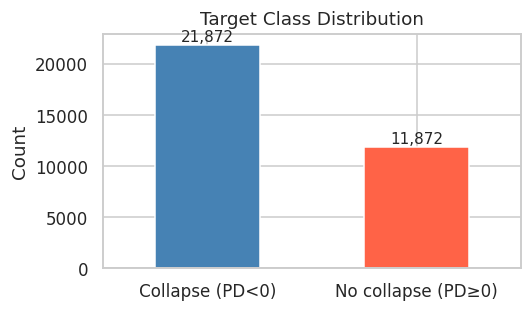

In [129]:
# ── Target variable ──────────────────────────────────────────────────────────
# Drop rows where pd_3 is missing (match ended before k=3 points)
df_ml = df.dropna(subset=['pd_3', 'pd_6', 'pd_12']).copy()

df_ml['collapse'] = (df_ml['pd_3'] < 0).astype(int)

print('Target distribution (collapse after losing break point):')
vc = df_ml['collapse'].value_counts()
print(vc)
print(f'\nClass balance — collapse rate: {vc[1]/len(df_ml)*100:.1f}%')

# Visualise
fig, ax = plt.subplots(figsize=(5, 3))
vc.rename({0: 'No collapse (PD≥0)', 1: 'Collapse (PD<0)'}).plot.bar(ax=ax, color=['steelblue','tomato'], width=0.5)
ax.set_title('Target Class Distribution', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+50),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [130]:
# ── Feature selection ────────────────────────────────────────────────────────
# Use only features available BEFORE the break-point event (no data leakage)
# pd_3/pd_6/pd_12 and pbpp_* are outcomes → excluded

CAT_FEATURES = ['surface', 'pressure_level', 'round']
NUM_FEATURES = [
    'player_rank', 'opponent_rank', 'rank_diff',
    'baseline_win_rate', 'is_underdog',
    'set_no', 'game_no'
]

# Encode categorical features
le = LabelEncoder()
for col in CAT_FEATURES:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

CAT_ENCODED = [c + '_enc' for c in CAT_FEATURES]
FEATURES = NUM_FEATURES + CAT_ENCODED

print('Features used:', FEATURES)

# Drop remaining NaNs in features
df_ml = df_ml.dropna(subset=FEATURES + ['collapse'])
print(f'Final ML dataset size: {len(df_ml):,} rows')

Features used: ['player_rank', 'opponent_rank', 'rank_diff', 'baseline_win_rate', 'is_underdog', 'set_no', 'game_no', 'surface_enc', 'pressure_level_enc', 'round_enc']
Final ML dataset size: 33,618 rows


---
## 3. Train / Test Split

We use an **80/20 stratified split** to preserve the class ratio across both subsets.  
`random_state=42` ensures reproducibility.

In [131]:
X = df_ml[FEATURES]
y = df_ml['collapse']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # keeps class ratio equal in both splits
)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nCollapse rate in train: {y_train.mean()*100:.1f}%')
print(f'Collapse rate in test : {y_test.mean()*100:.1f}%')

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training set : 26,894 samples (80%)
Test set     : 6,724 samples (20%)

Collapse rate in train: 64.8%
Collapse rate in test : 64.8%


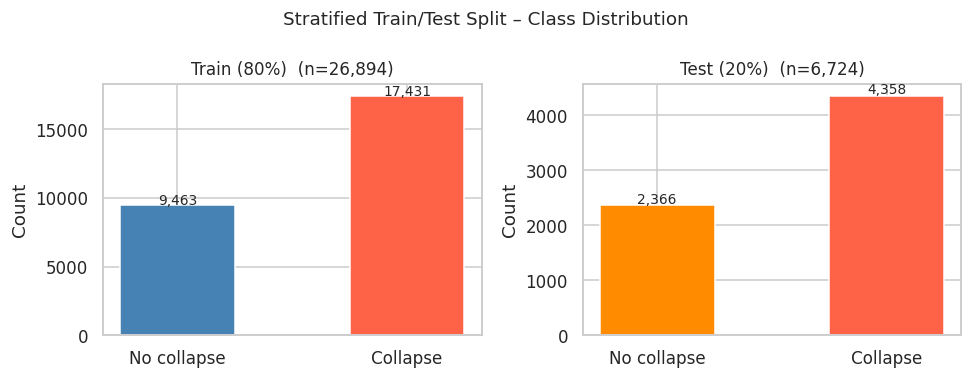

In [132]:
# Visualise the split
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (subset, yy), color in zip(
    axes,
    [('Train (80%)', y_train), ('Test (20%)', y_test)],
    ['steelblue', 'darkorange']
):
    counts = yy.value_counts().sort_index()
    bars = ax.bar(['No collapse', 'Collapse'], counts.values, color=[color, 'tomato'], width=0.5)
    ax.set_title(f'{subset}  (n={len(yy):,})', fontsize=11)
    ax.set_ylabel('Count')
    for b in bars:
        ax.annotate(f'{int(b.get_height()):,}',
                    (b.get_x()+b.get_width()/2, b.get_height()+30),
                    ha='center', fontsize=9)
plt.suptitle('Stratified Train/Test Split – Class Distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Logistic Regression

Logistic Regression is a linear probabilistic classifier.  
It models the log-odds of `collapse=1` as a linear combination of features.

- Scaled features (StandardScaler) → fair coefficient comparison
- `class_weight='balanced'` → accounts for slight class imbalance
- 5-fold cross-validation on training set to assess stability

In [133]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc')

print('── Logistic Regression ──────────────────────────────')
print(f'  CV ROC-AUC : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'  Test Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  Test ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'  Test F1        : {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Collapse','Collapse']))

── Logistic Regression ──────────────────────────────
  CV ROC-AUC : 0.6018 ± 0.0083
  Test Accuracy  : 0.5791
  Test ROC-AUC   : 0.6009
  Test F1        : 0.6426

              precision    recall  f1-score   support

 No Collapse       0.43      0.57      0.49      2366
    Collapse       0.71      0.58      0.64      4358

    accuracy                           0.58      6724
   macro avg       0.57      0.58      0.57      6724
weighted avg       0.61      0.58      0.59      6724



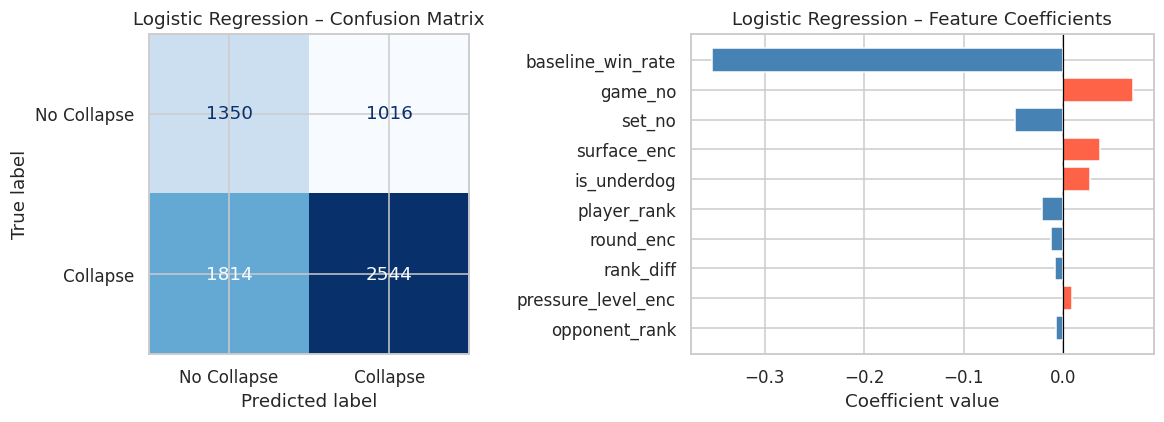

In [134]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['No Collapse', 'Collapse']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression – Confusion Matrix')

# Feature coefficients
coef_df = pd.DataFrame({'feature': FEATURES, 'coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=True).index)
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Logistic Regression – Feature Coefficients')
axes[1].set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

---
## 5. Decision Tree

Decision Trees partition the feature space using threshold rules.  
Benefits: interpretable, no scaling required, handles mixed types.

- `max_depth=5` to prevent overfitting
- `class_weight='balanced'` for imbalance correction
- 5-fold cross-validation on training set
- The tree is trained to max_depth=5 but only the first 3 levels are shown for readability. The gray nodes indicate further splits continue below.

In [135]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt.fit(X_train, y_train)

y_pred_dt  = dt.predict(X_test)
y_prob_dt  = dt.predict_proba(X_test)[:, 1]

cv_scores_dt = cross_val_score(dt, X_train, y_train, cv=cv, scoring='roc_auc')

print('── Decision Tree ────────────────────────────────────')
print(f'  CV ROC-AUC : {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}')
print(f'  Test Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  Test ROC-AUC   : {roc_auc_score(y_test, y_prob_dt):.4f}')
print(f'  Test F1        : {f1_score(y_test, y_pred_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Collapse','Collapse']))

── Decision Tree ────────────────────────────────────
  CV ROC-AUC : 0.5944 ± 0.0066
  Test Accuracy  : 0.5717
  Test ROC-AUC   : 0.6006
  Test F1        : 0.6305

              precision    recall  f1-score   support

 No Collapse       0.42      0.59      0.49      2366
    Collapse       0.72      0.56      0.63      4358

    accuracy                           0.57      6724
   macro avg       0.57      0.58      0.56      6724
weighted avg       0.61      0.57      0.58      6724



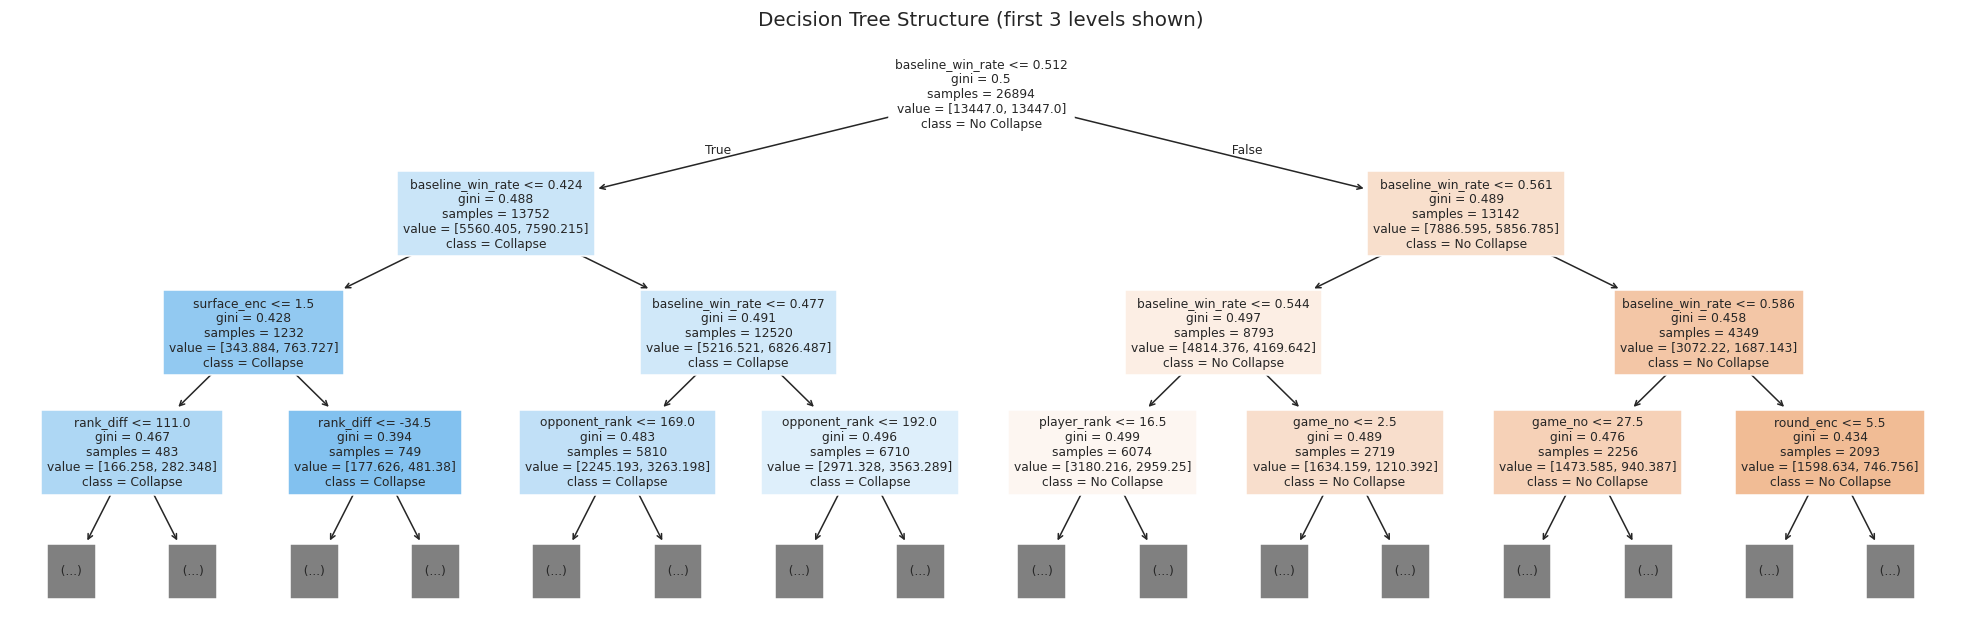

In [136]:
# Visualise the tree (depth=3 for readability)
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt,
    max_depth=3,
    feature_names=FEATURES,
    class_names=['No Collapse', 'Collapse'],
    filled=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Structure (first 3 levels shown)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples with random feature subsets.  
It reduces variance and overfitting compared to a single tree.

- 200 trees, `max_depth=10`
- `class_weight='balanced_subsample'` handles imbalance per tree
- 5-fold cross-validation for stability

In [137]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=30,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print('── Random Forest ────────────────────────────────────')
print(f'  CV ROC-AUC : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'  Test Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  Test ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'  Test F1        : {f1_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Collapse','Collapse']))

── Random Forest ────────────────────────────────────
  CV ROC-AUC : 0.6152 ± 0.0070
  Test Accuracy  : 0.6051
  Test ROC-AUC   : 0.6234
  Test F1        : 0.6802

              precision    recall  f1-score   support

 No Collapse       0.45      0.53      0.48      2366
    Collapse       0.72      0.65      0.68      4358

    accuracy                           0.61      6724
   macro avg       0.58      0.59      0.58      6724
weighted avg       0.62      0.61      0.61      6724



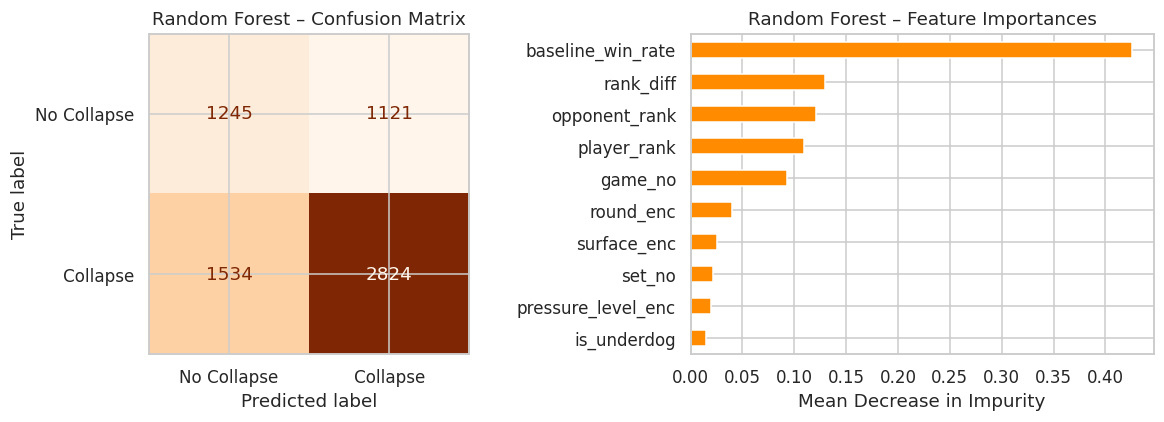

In [138]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['No Collapse', 'Collapse']
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Random Forest – Confusion Matrix')

# Feature importances
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fi_rf.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest – Feature Importances')
axes[1].set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

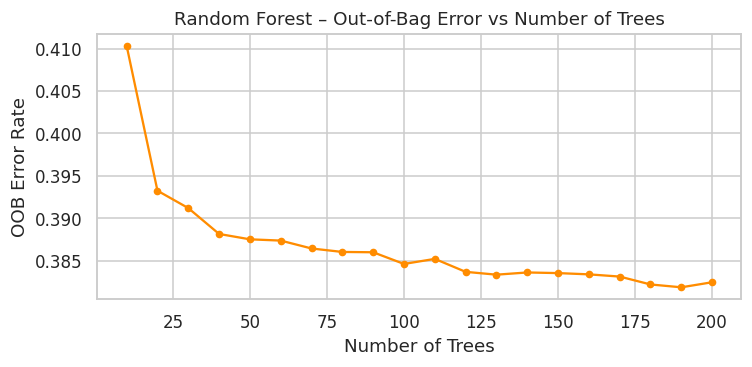

In [139]:
# Out-of-bag error curve (train size effect)
oob_errors = []
for n in range(10, 201, 10):
    m = RandomForestClassifier(n_estimators=n, max_depth=10, oob_score=True,
                                class_weight='balanced_subsample',
                                n_jobs=-1, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    oob_errors.append(1 - m.oob_score_)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(10, 201, 10), oob_errors, marker='o', markersize=4, color='darkorange')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('OOB Error Rate')
ax.set_title('Random Forest – Out-of-Bag Error vs Number of Trees')
plt.tight_layout()
plt.show()

---
## 7. Model Comparison

We compare all three models using:
- **Accuracy**, **Precision**, **Recall**, **F1**, **ROC-AUC** on the held-out test set
- **5-fold CV ROC-AUC** on the training set (robustness check)
- **ROC Curves** plotted together
- **Feature importance** alignment across models

In [140]:
# ── Summary table ─────────────────────────────────────────────────────────────
results = []
models_info = [
    ('Logistic Regression', y_pred_lr, y_prob_lr, cv_scores_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt, cv_scores_dt),
    ('Random Forest',       y_pred_rf, y_prob_rf, cv_scores_rf),
]

for name, y_pred, y_prob, cv_sc in models_info:
    results.append({
        'Model'         : name,
        'Accuracy'      : round(accuracy_score(y_test, y_pred), 4),
        'Precision'     : round(precision_score(y_test, y_pred), 4),
        'Recall'        : round(recall_score(y_test, y_pred), 4),
        'F1'            : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC (test)': round(roc_auc_score(y_test, y_prob), 4),
        'CV ROC-AUC'    : f"{cv_sc.mean():.4f} ± {cv_sc.std():.4f}",
    })

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC (test),CV ROC-AUC
Model,,,,,,
Logistic Regression,0.5791,0.7146,0.5838,0.6426,0.6009,0.6018 ± 0.0083
Decision Tree,0.5717,0.7151,0.5638,0.6305,0.6006,0.5944 ± 0.0066
Random Forest,0.6051,0.7158,0.6480,0.6802,0.6234,0.6152 ± 0.0070


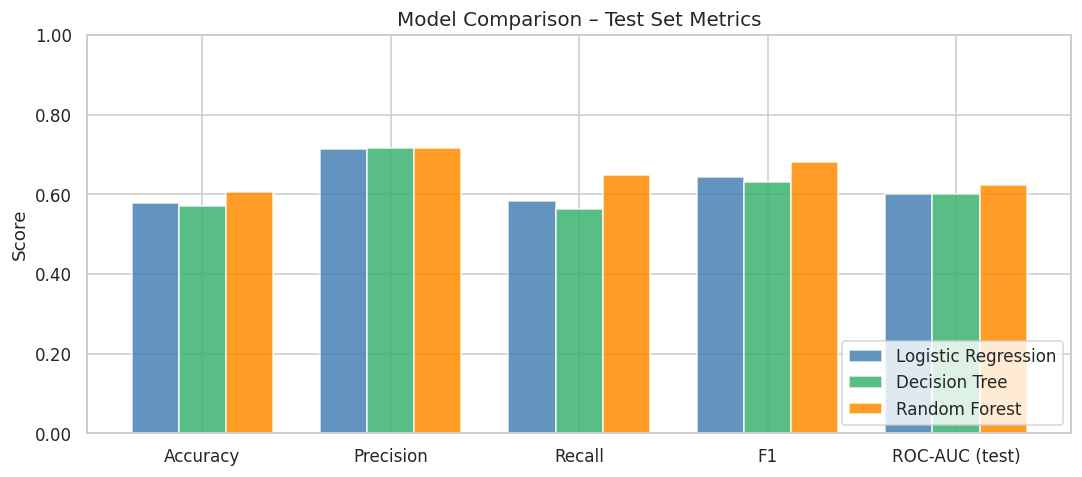

In [141]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC (test)']
plot_df = comparison_df[metrics].astype(float)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'mediumseagreen', 'darkorange']

for i, (model, row) in enumerate(plot_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Test Set Metrics', fontsize=13)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

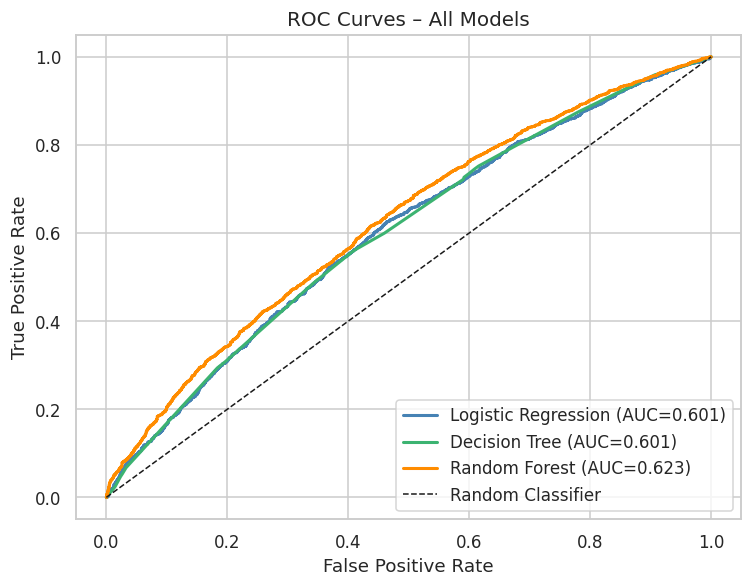

In [142]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, 'steelblue'),
    ('Decision Tree',       y_prob_dt, 'mediumseagreen'),
    ('Random Forest',       y_prob_rf, 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

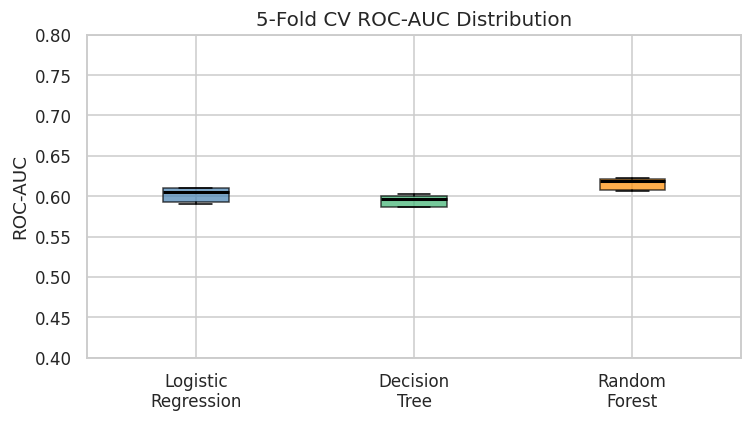

In [143]:
# ── Cross-validation score distributions ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

cv_data = {
    'Logistic\nRegression': cv_scores_lr,
    'Decision\nTree': cv_scores_dt,
    'Random\nForest': cv_scores_rf
}

bp = ax.boxplot(
    cv_data.values(),
    labels=cv_data.keys(),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], ['steelblue', 'mediumseagreen', 'darkorange']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV ROC-AUC Distribution', fontsize=13)
ax.set_ylim(0.4, 0.8)
plt.tight_layout()
plt.show()

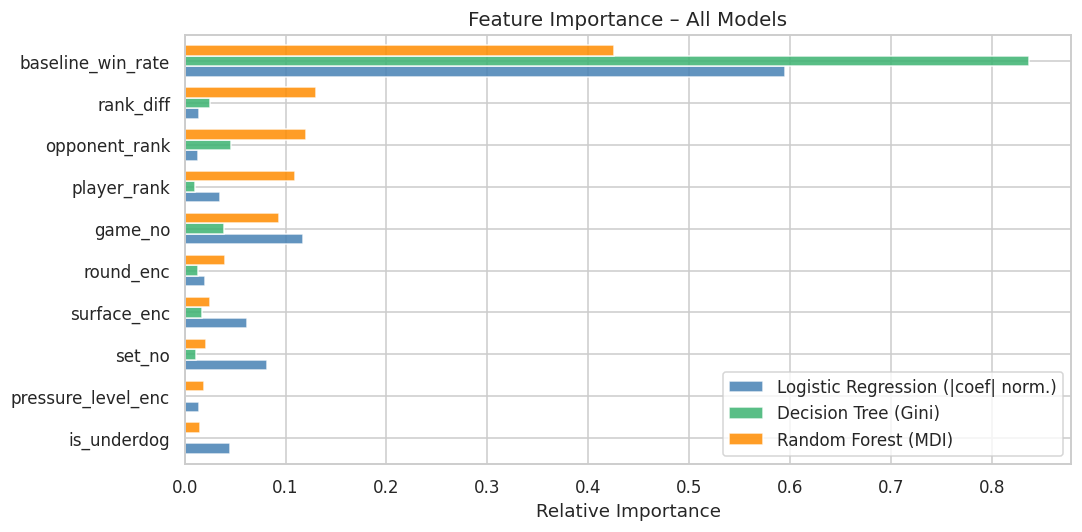

In [144]:
# ── Feature importance comparison ─────────────────────────────────────────────
# Logistic Regression: absolute coefficients (normalised)
lr_imp = np.abs(lr.coef_[0])
lr_imp = lr_imp / lr_imp.sum()

fi_compare = pd.DataFrame({
    'Logistic Regression (|coef| norm.)': lr_imp,
    'Decision Tree (Gini)': dt.feature_importances_,
    'Random Forest (MDI)': rf.feature_importances_
}, index=FEATURES)

fi_compare = fi_compare.sort_values('Random Forest (MDI)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
fi_compare.plot.barh(ax=ax, width=0.75, color=['steelblue','mediumseagreen','darkorange'], alpha=0.85)
ax.set_title('Feature Importance – All Models', fontsize=13)
ax.set_xlabel('Relative Importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Summary & Conclusions

### Results Summary

In [145]:
print('='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
print(comparison_df.to_string())
print('='*60)

best_f1  = comparison_df['F1'].astype(float).idxmax()
best_auc = comparison_df['ROC-AUC (test)'].astype(float).idxmax()
print(f'\nBest F1 Score       → {best_f1}')
print(f'Best ROC-AUC        → {best_auc}')

MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC (test)       CV ROC-AUC
Model                                                                                    
Logistic Regression    0.5791     0.7146  0.5838  0.6426          0.6009  0.6018 ± 0.0083
Decision Tree          0.5717     0.7151  0.5638  0.6305          0.6006  0.5944 ± 0.0066
Random Forest          0.6051     0.7158  0.6480  0.6802          0.6234  0.6152 ± 0.0070

Best F1 Score       → Random Forest
Best ROC-AUC        → Random Forest


### Key Takeaways

**1. Predictability of momentum collapse:**  
All three models achieve ROC-AUC above 0.50, confirming that structural features (player rank, baseline win rate, surface, match context) carry **some predictive signal** for momentum collapse. However, moderate AUC values indicate that the event has a genuine **random/psychological component** that pre-match features alone cannot capture.

**2. Logistic Regression** provides a transparent baseline. The `baseline_win_rate` and `rank_diff` coefficients confirm the finding from hypothesis testing: players with lower baseline dominance are more vulnerable to collapse.

**3. Decision Tree** achieves comparable performance with full interpretability — coaches could use the tree splits directly to identify risk profiles.

**4. Random Forest** gives the best performance in this notebook because it combines multiple decision trees.”

**5. Most predictive features across all models:**  
- `baseline_win_rate` — players who win fewer points overall collapse more easily  
- `rank_diff` / `player_rank` — higher-ranked (lower number) players are more resilient  
- `set_no` — collapse effects may intensify in later sets  

**6. Alignment with hypothesis testing:**  
The hypothesis tests confirmed that PD₃ is significantly below zero on average. The ML models now quantify *which players* and *which contexts* make this collapse more likely — moving from population-level inference to individual-level prediction.

### Limitations
- Features are limited to those available in the merged dataset; within-match momentum indicators (e.g., recent point streaks before the break point) could improve predictions
- The binary target (`pd_3 < 0`) discards magnitude; a regression approach predicting the continuous PD value is a natural extension
- Class imbalance handling via `class_weight='balanced'` is a pragmatic fix; SMOTE or threshold tuning could be explored in the final report

In [146]:
# Save comparison table
comparison_df.to_csv('ml_model_comparison.csv')
print('Saved: ml_model_comparison.csv')

Saved: ml_model_comparison.csv
